# 📓 Linear Regression from Scratch

### 🎯 Objective
- Implement a linear regression model using gradient descent.
- Derive the gradient updates, write a scikit-learn-like class, and evaluate using synthetic data.
- Compare the result of the same with library code output
- Use R2-Score and Mean Absolute Percentage error as Performance metric on test data

## 📊 Generate Synthetic Data

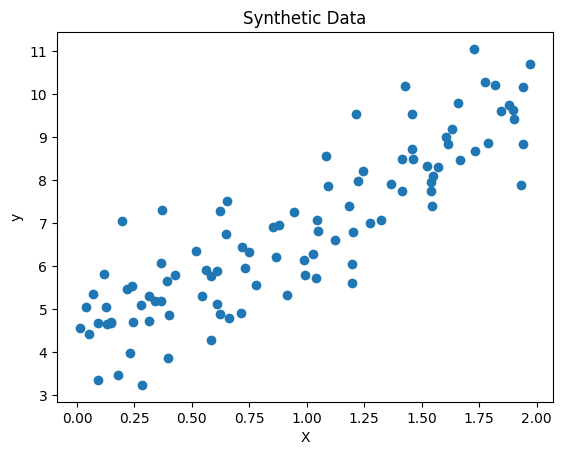

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Plot
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()


## Do Train-Test Split (75%-25%)

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Do the Linear Regression with Scikit-Learn Library

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import pandas as pd
model = LinearRegression()
model.fit(X_train, y_train)



y_test_pred = model.predict(X_test)

mae_test = mean_absolute_percentage_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)


print(f"Test MAE: {mae_test:.2f}")
print(f"Train R-squared: {r2_test:.2f}")

Test MAE: 0.08
Train R-squared: 0.83


## Do Ridge and Lasso Regression and Compare the evaluation metrics in a table

In [4]:
from sklearn.linear_model import  Ridge, Lasso
#Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_test_pred = ridge.predict(X_test)



rid_mae_test = mean_absolute_percentage_error(y_test, y_test_pred)
rid_r2_test = r2_score(y_test, y_test_pred)


#LASSO
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)


# y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

# Evaluation
# lass_mae_train = mean_absolute_percentage_error(y_train, y_train_pred)
# lass_r2_train = r2_score(y_train, y_train_pred)

lass_mae_test = mean_absolute_percentage_error(y_test, y_test_pred)
lass_r2_test = r2_score(y_test, y_test_pred)

result_df = pd.DataFrame(columns=["Model", "R2-Score (Test)","MSE(Test)"])
result_df.loc[len(result_df)] = ["Ridge Regression", rid_r2_test,rid_mae_test]
result_df.loc[len(result_df)] = ["Lasso Regression", lass_r2_test, lass_mae_test]
result_df

,Model,R2-Score (Test),MSE(Test)
0,Ridge Regression,0.825999,0.082412
1,Lasso Regression,0.809082,0.082640


## Custom Implementation

## 🧮 Derive the Gradient Updates
Use the chain rule to derive the gradients of the loss function (Mean Square Error):

$$ \text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2 $$

Derive:
- ∂Loss/∂m
- ∂Loss/∂c

Write the derivation here/add screenshot of your derivation here:

### Mean Squared Error Loss

$
\text{Loss} = \frac{1}{N}\sum_{i=1}^{N} \left(y_i - (m x_i + c)\right)^2
$

---

### Gradient w.r.t. $m$

$
\frac{\partial \text{Loss}}{\partial m}
= \frac{1}{N}\sum_{i=1}^{N} 2\left(y_i - (m x_i + c)\right)
\cdot \frac{\partial}{\partial m}\left(y_i - (m x_i + c)\right)
$

$
\frac{\partial}{\partial m}\left(y_i - (m x_i + c)\right) = -x_i
$

$
\boxed{
\frac{\partial \text{Loss}}{\partial m}
= -\frac{2}{N}\sum_{i=1}^{N} x_i\left(y_i - (m x_i + c)\right)
}
$

---

### Gradient w.r.t. $c$

$
\frac{\partial \text{Loss}}{\partial c}
= \frac{1}{N}\sum_{i=1}^{N} 2\left(y_i - (m x_i + c)\right)
\cdot \frac{\partial}{\partial c}\left(y_i - (m x_i + c)\right)
$

$
\frac{\partial}{\partial c}\left(y_i - (m x_i + c)\right) = -1
$

$
\boxed{
\frac{\partial \text{Loss}}{\partial c}
= -\frac{2}{N}\sum_{i=1}^{N} \left(y_i - (m x_i + c)\right)
}
$


## 🧠 Custom Linear Regression Class

In [5]:
import numpy as np

class MyLinearRegression:
    def __init__(self):
       self.weights = None
       self.bias = None
       self.loss_history = []

    def fit(self, X, y, lr=0.01, n_iters=1000):
        X = np.array(X)
        y = np.array(y)

        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if y.ndim > 1:
            y = y.ravel()

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []
        for i in range(n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= lr * dw
            self.bias -= lr * db

            loss = (1 / n_samples) * np.sum(error ** 2)
            self.loss_history.append(loss)


        self.coef_ = self.weights
        self.intercept_ = self.bias

    def predict(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.dot(X, self.weights) + self.bias


    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
        self.fit(X, y, lr, n_iters)
        return self.predict(X)


## 🔁 Train the Model and Visualize the Fit

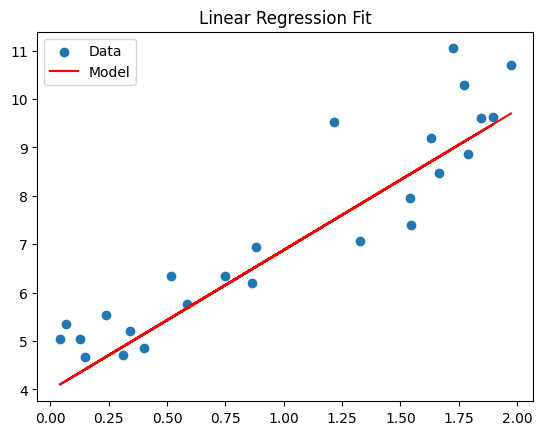

Learned coefficients (m, c): [2.89692654] 3.9826474845013564


In [6]:

model = MyLinearRegression()
model.fit(X_train, y_train, lr=0.1, n_iters=100)

y_pred_custom = model.predict(X_test)

plt.scatter(X_test, y_test, label="Data")
plt.plot(X_test, y_pred_custom, color="red", label="Model")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

print("Learned coefficients (m, c):", model.coef_, model.intercept_)


## 📉 Plot the Loss Curve

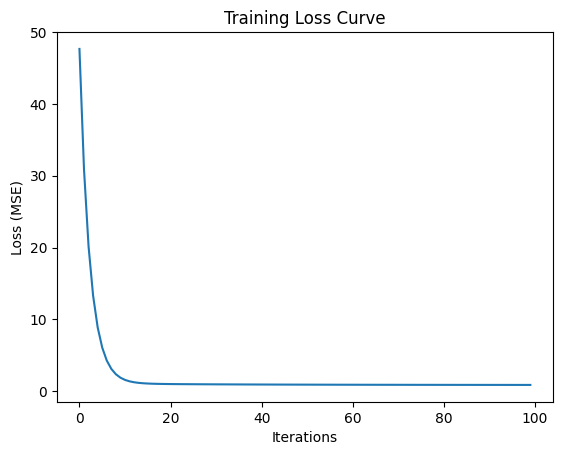

In [7]:
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.show()


## 🌟 Bonus Task: Stochastic Gradient Descent
Implement a class `MyLinearRegressionSGD` that uses one training sample per iteration to update weights.

In [8]:
import numpy as np

class MyLinearRegressionSGD:
    def __init__(self):
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y, lr=0.01, n_iters=1000, shuffle=True):
        X = np.array(X)
        y = np.array(y)

        # Shape safety
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if y.ndim > 1:
            y = y.ravel()

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(n_iters):
            if shuffle:
                idx = np.random.randint(0, n_samples)
            else:
                idx = _ % n_samples

            xi = X[idx]          # shape: (n_features,)
            yi = y[idx]

            # Prediction for one sample
            y_pred = np.dot(xi, self.weights) + self.bias

            # Gradients (single sample)
            error = y_pred - yi
            dw = xi * error
            db = error

            # Update
            self.weights -= lr * dw
            self.bias -= lr * db

            # Track loss (single-sample MSE)
            self.loss_history.append(error ** 2)

        # sklearn-style attributes
        self.coef_ = self.weights
        self.intercept_ = self.bias

    def predict(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return X @ self.weights + self.bias

    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
        self.fit(X, y, lr, n_iters)
        return self.predict(X)


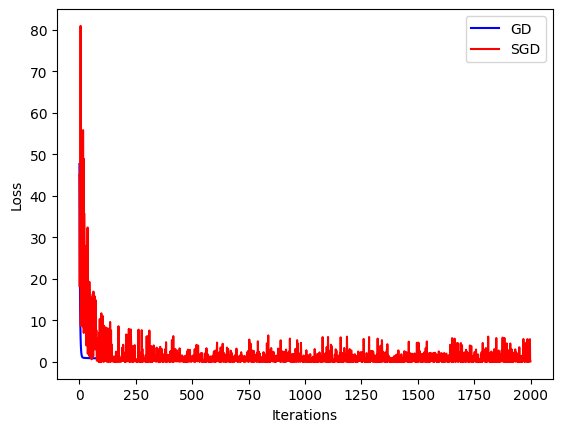

In [9]:
model_sgd = MyLinearRegressionSGD()
model_sgd.fit(X_train, y_train, lr=0.01, n_iters=2000)


plt.plot(model.loss_history, label="GD", color="blue")
plt.plot(model_sgd.loss_history, label="SGD", color="red")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Visualize the prediction result of Library version and Custom regression code created

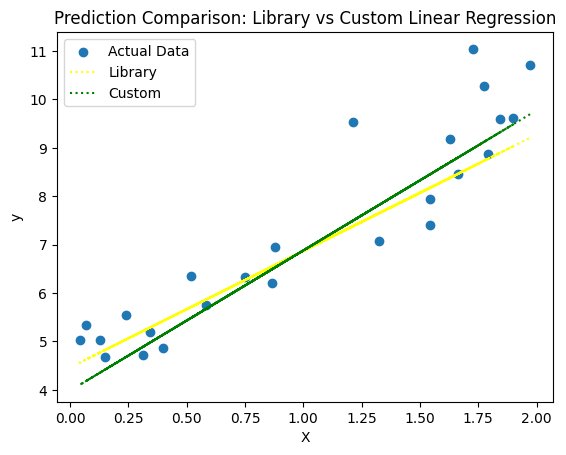

In [12]:
plt.figure()

# Actual data
plt.scatter(X_test, y_test, label="Actual Data")

# Predictions
plt.plot(X_test, y_test_pred, linestyle="dotted",label="Library",color="yellow")
plt.plot(X_test, y_pred_custom, linestyle="dotted", label="Custom",color="green")

# # plt.scatter(X_test, y_test, s=60, label="Actual Data")

# plt.plot(X_test, y_pred,
#          linestyle="--", linewidth=2, label="Library")

# plt.plot(X_test, y_pred,
#          linestyle=":", linewidth=3, label="Custom")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Prediction Comparison: Library vs Custom Linear Regression")
plt.show()

## ✅ Checklist
- [ ] Did linear regression using scikit-learn API
- [ ] Did Ridge and Lasso regression and compiled the result (R2 and MAPE) as a table
- [ ] Derived gradients using chain rule
- [ ] Implemented custom Linear Regression class
- [ ] Trained using gradient descent
- [ ] Visualized predictions and loss
- [ ] Implemented stochastic gradient descent (bonus)
- [ ] Visualized predictions and loss for stochastic gradient descent (bonus)
- [ ] Visualize the prediction result of Library version and custom version